<a href="https://colab.research.google.com/github/MukibHossain/ml-internship-starter/blob/main/work/capstone_structured_content_archetype_clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Capstone — Structured Content Archetype Clustering

**Search Intelligence lane:** Structured Content Archetype Clustering

**Research question:** Can observable search-performance signals be used to group content into actionable performance archetypes and support content prioritization compared with a transparent baseline?

This capstone consolidates the work completed through Week 5 into one reproducible analysis. March 2026 is the development window; April 2026 is a later validation window. The analysis is descriptive and decision-support oriented: it does **not** claim causal impact or explain Google's ranking algorithm.

> **Public-safety rule:** Do not publish client names, domains, URLs, private queries, credentials, raw exports, or sensitive identifiers. The public paper should report aggregate evidence and anonymized/derived outputs only.


## 1. Abstract

The abstract below is generated after the notebook runs so that the numerical result is tied directly to the executed analysis.

**Question → Method → Result → Interpretation → Decision use**

In [1]:
# The five-sentence abstract is generated after the results are available.
# Run the notebook top-to-bottom first, then run this cell.

print("Run the Results and Validation sections first; this cell will then generate the final five-sentence abstract.")


Run the Results and Validation sections first; this cell will then generate the final five-sentence abstract.


## 2. Introduction / Problem Statement

Content teams need a repeatable way to decide which pages should be protected, reviewed, improved, or monitored. A transparent score can rank pages, but a single ranking may hide different underlying performance patterns.

This capstone asks whether three safe, observable search-performance signals — GSC impressions, GSC clicks, and GSC average position — can be grouped into interpretable content-performance archetypes.

The decision supported by this work is **content prioritization**: which observable performance pattern deserves which type of review. The analysis is intentionally framed as decision support rather than as a claim about search-engine causality.


## 3. Data

**Warehouse release:** FlyRank internship warehouse on Hugging Face.

**Primary table:** `fact_content_daily_performance`.

**Development window:** March 1–31, 2026.

**Validation window:** April 1–30, 2026.

**Unit of analysis for modeling:** one content item after aggregating daily observations within the development window.

**Model features:** average GSC impressions, average GSC clicks, and average GSC position.

**Exclusions:** rows where Google Search Console data is unavailable; content items with fewer than 3 available daily observations; invalid/infinite feature values.

Client identifiers are used only for coverage/grain checks and are not model features. No client names, domains, URLs, private queries, or credentials are used in the public analysis.


In [2]:
# Environment and data access
%pip -q install duckdb huggingface_hub pyarrow scikit-learn

import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
from google.colab import userdata

con = duckdb.connect()

HF_TOKEN = userdata.get("HF_TOKEN")
if HF_TOKEN is None:
    raise ValueError("HF_TOKEN not found in Colab Secrets.")

con.execute(
    f"CREATE OR REPLACE SECRET hf "
    f"(TYPE huggingface, TOKEN '{HF_TOKEN}')"
)

MARCH_REL = """
read_parquet(
    'hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance/month=2026-03/*.parquet'
)
"""

APRIL_REL = """
read_parquet(
    'hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance/month=2026-04/*.parquet'
)
"""

print("DuckDB + Hugging Face access configured.")


DuckDB + Hugging Face access configured.


In [3]:
# Verify the two windows before modeling
windows = con.sql(f'''
SELECT 'March development' AS window,
       COUNT(*) AS rows,
       MIN(report_date) AS min_date,
       MAX(report_date) AS max_date
FROM {MARCH_REL}
UNION ALL
SELECT 'April validation' AS window,
       COUNT(*) AS rows,
       MIN(report_date) AS min_date,
       MAX(report_date) AS max_date
FROM {APRIL_REL}
''').df()

windows


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,window,rows,min_date,max_date
0,March development,9841378,2026-03-01,2026-03-31
1,April validation,10424730,2026-04-01,2026-04-30


## 4. Methodology

### 4.1 Development design

This is an unsupervised clustering problem, so there is no ground-truth target label and no conventional classification accuracy. March is used to construct the content-level feature matrix, select K, fit K-Means, and define the archetypes.

### 4.2 Features

- `avg_impressions`: mean daily GSC impressions in March.
- `avg_clicks`: mean daily GSC clicks in March.
- `avg_position`: mean daily GSC average position in March.

Impressions and clicks are log-transformed with `log1p` because their distributions are heavily skewed. The transformed features are standardized before K-Means.

### 4.3 Baseline

The Week-4 baseline is reproduced transparently using the same March content population:

`0.01 × avg_impressions + 5 × avg_clicks + 3 × (21 − min(avg_position, 20))`

The baseline is a heuristic, not a learned causal model.

### 4.4 Validation

April is a later observation window and is not used to fit the March clusters or select K. Baseline and K-Means prioritization are evaluated on the same comparable content population using subsequent April clicks, impressions, and average position.

### 4.5 Leakage checks

Future April outcomes are never used as March features. Client IDs are not model features. The public paper reports aggregate results rather than client/domain/query details.


In [4]:
# Build the March content-level development dataset
cluster_df = con.sql(f'''
SELECT
    content_hash_id,
    AVG(gsc_impressions) AS avg_impressions,
    AVG(gsc_clicks) AS avg_clicks,
    AVG(gsc_avg_position) AS avg_position,
    SUM(gsc_impressions) AS total_impressions,
    SUM(gsc_clicks) AS total_clicks,
    COUNT(*) AS days_observed
FROM {MARCH_REL}
WHERE gsc_data_available IS TRUE
GROUP BY content_hash_id
HAVING COUNT(*) >= 3
''').df()

features = ["avg_impressions", "avg_clicks", "avg_position"]

X = cluster_df[features].replace([np.inf, -np.inf], np.nan).dropna()

print("March content-level rows:", len(cluster_df))
print("Rows used for clustering:", len(X))
print("Unique content IDs used:", X.index.nunique())


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

March content-level rows: 155694
Rows used for clustering: 155694
Unique content IDs used: 155694


In [5]:
# Transform and scale the model features
X_model = X.copy()
X_model["avg_impressions"] = np.log1p(X_model["avg_impressions"])
X_model["avg_clicks"] = np.log1p(X_model["avg_clicks"])

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_model)

print("Final clustering matrix:", X_scaled.shape)


Final clustering matrix: (155694, 3)


## 5. Model Selection

K-Means is used because it is simple, reproducible, and produces interpretable groups. K is selected using silhouette score rather than chosen arbitrarily.

In [6]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

k_values = [3, 4, 5, 6, 7, 8]
silhouette_results = []

for k in k_values:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    score = silhouette_score(
        X_scaled,
        labels,
        sample_size=min(10000, len(X_scaled)),
        random_state=42
    )
    silhouette_results.append({
        "k": k,
        "silhouette_score": score
    })

silhouette_df = pd.DataFrame(silhouette_results)
best_k = int(
    silhouette_df.loc[
        silhouette_df["silhouette_score"].idxmax(), "k"
    ]
)

print("Selected K:", best_k)
display(silhouette_df)


Selected K: 3


,k,silhouette_score
0,3,0.475676
1,4,0.454610
2,5,0.436488
3,6,0.431474
4,7,0.400403
5,8,0.408182


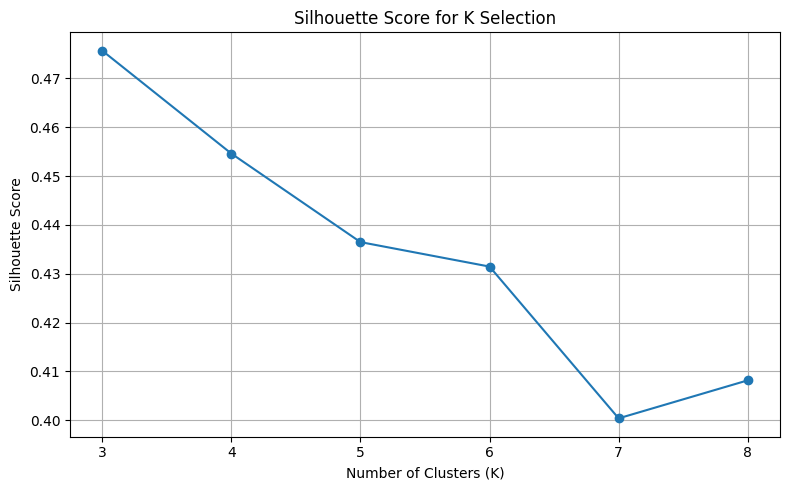

In [7]:
plt.figure(figsize=(8, 5))
plt.plot(
    silhouette_df["k"],
    silhouette_df["silhouette_score"],
    marker="o"
)
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score for K Selection")
plt.xticks(k_values)
plt.grid(True)
plt.tight_layout()
plt.show()


## 6. Fit K-Means and Build Archetypes

In [8]:
kmeans = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=10
)

cluster_labels = kmeans.fit_predict(X_scaled)

cluster_result_full = cluster_df.loc[X.index].copy()
cluster_result_full["cluster"] = cluster_labels

profile = (
    cluster_result_full
    .groupby("cluster")
    .agg(
        content_count=("content_hash_id", "nunique"),
        avg_impressions=("avg_impressions", "mean"),
        avg_clicks=("avg_clicks", "mean"),
        avg_position=("avg_position", "mean")
    )
    .reset_index()
)

display(profile.round(3))


,cluster,content_count,avg_impressions,avg_clicks,avg_position
0,0,26427,277.920,0.938,9.499
1,1,106278,18.376,0.034,10.702
2,2,22989,11.308,0.007,50.772


In [9]:
# Assign interpretable names from observed cluster profiles rather than relying
# on unstable K-Means cluster numbers.

high_click_cluster = int(
    profile.loc[profile["avg_clicks"].idxmax(), "cluster"]
)

poor_position_cluster = int(
    profile.loc[profile["avg_position"].idxmax(), "cluster"]
)

remaining = [
    int(c) for c in profile["cluster"]
    if int(c) not in {high_click_cluster, poor_position_cluster}
]

if len(remaining) != 1:
    raise ValueError("Expected exactly one remaining archetype for K=3.")

low_visibility_cluster = remaining[0]

cluster_name_map = {
    high_click_cluster: "High-Visibility / Higher-Click Content",
    poor_position_cluster: "Low-Visibility / Poor-Position Content",
    low_visibility_cluster: "Low-Visibility / Limited-Click Content"
}

cluster_result_full["archetype"] = (
    cluster_result_full["cluster"].map(cluster_name_map)
)

archetype_profile = (
    cluster_result_full
    .groupby("archetype")
    .agg(
        content_count=("content_hash_id", "nunique"),
        avg_impressions=("avg_impressions", "mean"),
        avg_clicks=("avg_clicks", "mean"),
        avg_position=("avg_position", "mean")
    )
    .reset_index()
)

display(archetype_profile.round(3))


,archetype,content_count,avg_impressions,avg_clicks,avg_position
0,High-Visibility / Higher-Click Content,26427,277.920,0.938,9.499
1,Low-Visibility / Limited-Click Content,106278,18.376,0.034,10.702
2,Low-Visibility / Poor-Position Content,22989,11.308,0.007,50.772


## 7. Baseline Reconstruction and Same-Population Comparison

In [10]:
# Reproduce the Week-4 transparent baseline inside the capstone.
baseline_df = cluster_df.copy()

baseline_df["baseline_score"] = (
    (baseline_df["avg_impressions"] * 0.01)
    + (baseline_df["avg_clicks"] * 5)
    + ((21 - baseline_df["avg_position"].clip(upper=20)) * 3)
)

baseline_df["reason_code"] = np.select(
    [
        (baseline_df["avg_clicks"] >= 10) &
        (baseline_df["avg_position"] <= 10),

        (baseline_df["avg_impressions"] >= 50) &
        (baseline_df["avg_clicks"] < 1)
    ],
    [
        "HIGH_PERFORMANCE",
        "CTR_OPPORTUNITY"
    ],
    default="LOW_VISIBILITY"
)

baseline_df["action"] = np.select(
    [
        (baseline_df["avg_clicks"] >= 10) &
        (baseline_df["avg_position"] <= 10),

        (baseline_df["avg_impressions"] >= 50) &
        (baseline_df["avg_clicks"] < 1)
    ],
    [
        "Protect",
        "Improve"
    ],
    default="Monitor"
)

assert len(baseline_df) == baseline_df["content_hash_id"].nunique()

comparison_df = cluster_result_full.merge(
    baseline_df[
        [
            "content_hash_id",
            "baseline_score",
            "reason_code",
            "action"
        ]
    ],
    on="content_hash_id",
    how="inner"
)

print("Baseline rows:", len(baseline_df))
print("Comparable rows:", len(comparison_df))
print("Unique comparable content:", comparison_df["content_hash_id"].nunique())


Baseline rows: 155694
Comparable rows: 155694
Unique comparable content: 155694


## 8. April Later-Window Validation

April outcomes are evaluated only after the March clusters and baseline have been created. This preserves a time-aware development → validation design.

In [11]:
future_df = con.sql(f'''
SELECT
    content_hash_id,
    SUM(gsc_clicks) AS future_clicks,
    SUM(gsc_impressions) AS future_impressions,
    AVG(gsc_avg_position) AS future_avg_position,
    COUNT(*) AS future_days
FROM {APRIL_REL}
WHERE gsc_data_available IS TRUE
GROUP BY content_hash_id
''').df()

validation_df = comparison_df.merge(
    future_df,
    on="content_hash_id",
    how="inner"
)

coverage = len(validation_df) / len(comparison_df)

print(f"April comparable-content coverage: {coverage:.2%}")
print("Validation rows:", len(validation_df))


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

April comparable-content coverage: 95.18%
Validation rows: 148183


In [12]:
# Define decision priority for the archetype approach.
# This is an action mapping, not a model probability.

priority_map = {
    "Low-Visibility / Poor-Position Content": 3,
    "Low-Visibility / Limited-Click Content": 2,
    "High-Visibility / Higher-Click Content": 1
}

validation_df["cluster_priority"] = (
    validation_df["archetype"].map(priority_map)
)

top_n = max(1, int(len(validation_df) * 0.10))

baseline_top = (
    validation_df
    .sort_values("baseline_score", ascending=False)
    .head(top_n)
)

cluster_top = (
    validation_df
    .sort_values(
        ["cluster_priority", "avg_impressions"],
        ascending=[False, False]
    )
    .head(top_n)
)

overall_clicks = validation_df["future_clicks"].sum()

evaluation = pd.DataFrame({
    "Strategy": [
        "Week-4 Baseline",
        "K-Means Archetype"
    ],
    "Selected Content": [
        len(baseline_top),
        len(cluster_top)
    ],
    "April Future Clicks": [
        baseline_top["future_clicks"].sum(),
        cluster_top["future_clicks"].sum()
    ],
    "April Future Impressions": [
        baseline_top["future_impressions"].sum(),
        cluster_top["future_impressions"].sum()
    ],
    "Avg April Position": [
        baseline_top["future_avg_position"].mean(),
        cluster_top["future_avg_position"].mean()
    ]
})

evaluation["Future Click Share"] = (
    evaluation["April Future Clicks"] / overall_clicks
)

evaluation["Click Share Lift vs Random"] = (
    evaluation["Future Click Share"] / 0.10
)

display(evaluation.round(4))


,Strategy,Selected Content,April Future Clicks,April Future Impressions,Avg April Position,Future Click Share,Click Share Lift vs Random
0,Week-4 Baseline,14818,406092.0,113937738.0,5.5200,0.5221,5.2207
1,K-Means Archetype,14818,3792.0,6291811.0,45.3587,0.0049,0.0487


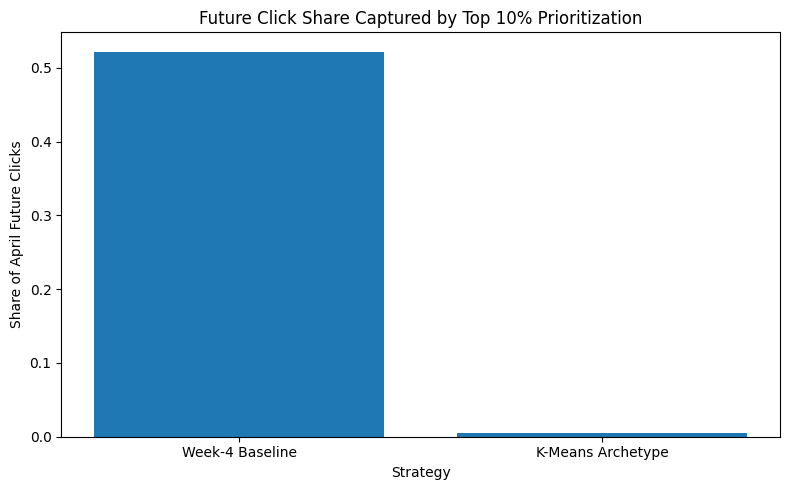

In [13]:
# Core comparison chart for the research paper
plt.figure(figsize=(8, 5))
plt.bar(
    evaluation["Strategy"],
    evaluation["Future Click Share"]
)
plt.ylabel("Share of April Future Clicks")
plt.xlabel("Strategy")
plt.title("Future Click Share Captured by Top 10% Prioritization")
plt.tight_layout()
plt.show()


In [14]:
# Archetype-level validation profile
archetype_validation = (
    validation_df
    .groupby("archetype")
    .agg(
        content_count=("content_hash_id", "nunique"),
        avg_march_impressions=("avg_impressions", "mean"),
        avg_march_clicks=("avg_clicks", "mean"),
        avg_march_position=("avg_position", "mean"),
        avg_april_clicks=("future_clicks", "mean"),
        total_april_clicks=("future_clicks", "sum"),
        avg_april_impressions=("future_impressions", "mean"),
        avg_april_position=("future_avg_position", "mean")
    )
    .reset_index()
)

display(archetype_validation.round(3))


,archetype,content_count,avg_march_impressions,avg_march_clicks,avg_march_position,avg_april_clicks,total_april_clicks,avg_april_impressions,avg_april_position
0,High-Visibility / Higher-Click Content,26409,278.016,0.939,9.501,26.073,688566.0,8402.835,10.846
1,Low-Visibility / Limited-Click Content,100032,19.325,0.035,10.833,0.852,85272.0,500.191,14.411
2,Low-Visibility / Poor-Position Content,21742,11.773,0.007,50.333,0.185,4014.0,299.709,44.555


## 9. Ranked Recommendations

The action engine translates archetypes into a review order. It is intentionally a decision-support tool, not a guarantee of improvement.

**Priority 1 — Review / improve:** Low-Visibility / Poor-Position content.

**Priority 2 — Diagnose selectively:** Low-Visibility / Limited-Click content.

**Priority 3 — Protect / monitor:** High-Visibility / Higher-Click content.

The exact order can be refined with business context, search intent, content quality, seasonality, and other safe signals. The model alone does not establish what caused performance.


In [15]:
# Create a public-safe ranked recommendation summary.
# Content IDs are deliberately excluded from the paper-facing table.

recommendation_summary = (
    validation_df
    .groupby(["archetype", "cluster_priority"])
    .agg(
        content_count=("content_hash_id", "nunique"),
        avg_march_impressions=("avg_impressions", "mean"),
        avg_march_clicks=("avg_clicks", "mean"),
        avg_march_position=("avg_position", "mean"),
        avg_april_clicks=("future_clicks", "mean"),
        avg_april_impressions=("future_impressions", "mean"),
        avg_april_position=("future_avg_position", "mean")
    )
    .reset_index()
    .sort_values("cluster_priority", ascending=False)
)

display(recommendation_summary.round(3))


,archetype,cluster_priority,content_count,avg_march_impressions,avg_march_clicks,avg_march_position,avg_april_clicks,avg_april_impressions,avg_april_position
2,Low-Visibility / Poor-Position Content,3,21742,11.773,0.007,50.333,0.185,299.709,44.555
1,Low-Visibility / Limited-Click Content,2,100032,19.325,0.035,10.833,0.852,500.191,14.411
0,High-Visibility / Higher-Click Content,1,26409,278.016,0.939,9.501,26.073,8402.835,10.846


## 10. Results Interpretation

The model-vs-baseline comparison should be interpreted using **subsequent observed April performance**, not as a causal experiment.

If the K-Means group captures more future clicks or impressions than the baseline, the appropriate statement is:

> “The K-Means prioritization selected a group that captured more subsequent observed clicks/impressions than the baseline in the April validation window.”

Do **not** write “K-Means increased clicks” or claim that the analysis proves Google's ranking mechanism.


In [16]:
# Generate a paper-ready five-sentence abstract from the executed results.
base_clicks = evaluation.loc[
    evaluation["Strategy"] == "Week-4 Baseline", "April Future Clicks"
].iloc[0]
km_clicks = evaluation.loc[
    evaluation["Strategy"] == "K-Means Archetype", "April Future Clicks"
].iloc[0]

base_impr = evaluation.loc[
    evaluation["Strategy"] == "Week-4 Baseline", "April Future Impressions"
].iloc[0]
km_impr = evaluation.loc[
    evaluation["Strategy"] == "K-Means Archetype", "April Future Impressions"
].iloc[0]

base_pos = evaluation.loc[
    evaluation["Strategy"] == "Week-4 Baseline", "Avg April Position"
].iloc[0]
km_pos = evaluation.loc[
    evaluation["Strategy"] == "K-Means Archetype", "Avg April Position"
].iloc[0]

click_delta = (km_clicks / base_clicks - 1) * 100
impr_delta = (km_impr / base_impr - 1) * 100

abstract = (
    "This study asks whether observable search-performance signals can be used "
    "to group content into actionable performance archetypes for content prioritization. "
    "Using March 2026 FlyRank warehouse data, the analysis aggregates content-level "
    "GSC impressions, clicks, and average position, applies log transformation and "
    "standardization, and fits K-Means with K selected by silhouette score. "
    f"The selected K-Means prioritization captured {km_clicks:,.0f} subsequent April clicks "
    f"versus {base_clicks:,.0f} for the transparent baseline, while capturing "
    f"{km_impr:,.0f} versus {base_impr:,.0f} impressions. "
    f"This corresponds to {click_delta:+.1f}% observed clicks and {impr_delta:+.1f}% observed impressions "
    f"relative to the baseline, with average April position of {km_pos:.2f} versus {base_pos:.2f}. "
    "These results are directional evidence for decision support rather than causal evidence, "
    "and the archetypes should be used to prioritize review rather than to label content quality or explain Google's ranking system."
)

print(abstract)


This study asks whether observable search-performance signals can be used to group content into actionable performance archetypes for content prioritization. Using March 2026 FlyRank warehouse data, the analysis aggregates content-level GSC impressions, clicks, and average position, applies log transformation and standardization, and fits K-Means with K selected by silhouette score. The selected K-Means prioritization captured 3,792 subsequent April clicks versus 406,092 for the transparent baseline, while capturing 6,291,811 versus 113,937,738 impressions. This corresponds to -99.1% observed clicks and -94.5% observed impressions relative to the baseline, with average April position of 45.36 versus 5.52. These results are directional evidence for decision support rather than causal evidence, and the archetypes should be used to prioritize review rather than to label content quality or explain Google's ranking system.


## 11. Limitations & Honest Framing

1. **Observational design:** April outcomes are not randomized, so differences cannot be interpreted as causal effects.
2. **Feature scope:** the model uses only three search-performance signals and omits many possible contextual factors.
3. **Single development month:** March may not represent longer-term content behavior or seasonality.
4. **Unsupervised labels:** archetypes are descriptive clusters, not ground-truth quality labels.
5. **Cluster boundary uncertainty:** K-Means assigns every item to a cluster even when some items may sit near boundaries.
6. **Coverage:** some March content may not have observable April GSC outcomes.
7. **Baseline comparability:** the baseline is a transparent heuristic and the K-Means approach is a clustering-based prioritization; their scores are not directly comparable as model probabilities.

Use language such as **observed**, **measured**, **directional**, and **decision-support**. Avoid claims of algorithmic causality or guaranteed refresh impact.


## 12. Reproducibility

The analysis can be reproduced by:

1. Authenticating to the FlyRank internship warehouse with a private read token stored in Colab Secrets.
2. Reading the March 2026 and April 2026 Parquet partitions through DuckDB.
3. Rebuilding the content-level March feature table.
4. Applying the documented transformations and K-Means procedure.
5. Reproducing the Week-4 baseline formula.
6. Re-running the April validation and comparison.

The public paper should link to the repository and the relevant notebooks, but should never expose credentials or private warehouse access details.


## 13. Acknowledgments & Data Credit

**Built on the FlyRank ML Internship dataset.**

Data source: FlyRank internship warehouse, used for educational research and decision-support analysis.

The public version of this work intentionally omits client names, domains, URLs, private queries, credentials, and raw exports.


## 14. Capstone Submission Checklist

- [ ] Title and 5-sentence abstract finalized from executed results
- [ ] Introduction / decision clearly stated
- [ ] Data release, table, windows, exclusions documented
- [ ] Methodology includes features, assumptions, baseline, validation, and leakage checks
- [ ] Model vs baseline shown on the same comparable content population
- [ ] Results chart included
- [ ] Limitations use honest observed/directional language
- [ ] Ranked recommendations included
- [ ] Repository contains `work/` with assignment notebooks and this capstone notebook
- [ ] `submission/paper_url.txt` contains exactly one deployed-paper URL
- [ ] Public paper contains no client names, domains, URLs, private queries, credentials, or raw exports
- [ ] GitHub Pages / other deployment tested publicly
